# Dimensionality Reduction

This notebook implements the **Dimensionality Reduction** stage of the CRISP-DM methodology for the *Mental Health in Technology-related Jobs* project.

Notebook 02 established the cleaned and prepared analytical representation of the OSMI Mental Health in Tech 2016 survey. The resulting representation contains the complete respondent population after data cleaning, missing-value handling, categorical encoding, and work-position feature engineering.

This notebook continues directly from that prepared representation.

It does **not** repeat the data-cleaning or feature-engineering decisions already completed in Notebook 02.

The purpose of this stage is to determine whether the prepared feature space contains unnecessary redundancy or lower-dimensional structure that can be represented more efficiently before clustering.

The analysis proceeds through:

1. validation of the prepared analytical matrix;
2. conservative unsupervised feature selection;
3. feature-redundancy analysis;
4. an explicit mixed-feature scaling decision;
5. Principal Component Analysis (PCA);
6. interpretation of PCA explained variance;
7. interpretation of PCA component loadings;
8. construction of the primary PCA representation;
9. Multidimensional Scaling (MDS) as a complementary representation;
10. methodological assessment of Locally Linear Embedding (LLE);
11. persistence and validation of the representations required by Notebook 04.

The objective is **not** to select a clustering model in this notebook.

Instead, this notebook produces defensible candidate representations that will be evaluated through the clustering experiments in Notebook 04.

## 1. Dimensionality-Reduction Objectives

### Business and analytical question

Can the prepared survey representation be reduced to a smaller number of dimensions while retaining enough structure to support meaningful unsupervised clustering?

### Methodological question

Which representation provides an appropriate balance between:

- reducing unnecessary dimensionality;
- limiting redundant information;
- preserving respondent-level structure;
- retaining meaningful variation;
- and remaining sufficiently interpretable for subsequent cluster analysis?

### Decision principle

No dimensionality-reduction technique is treated as automatically optimal.

Feature selection is used first to remove structural redundancy. PCA is then evaluated as the primary variance-based reduction method, while MDS provides a complementary distance-based representation.

The usefulness of the resulting representations is ultimately assessed through the clustering experiments in Notebook 04.

Therefore, a dimensionality-reduction diagnostic is treated as **evidence for a candidate representation**, rather than as proof that a particular clustering structure exists.

In [1]:
# Import the libraries required for data handling, dimensionality reduction,
# visualization, result interpretation, and persistence of analytical outputs.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mental_health_ml.data import load_dataset
from mental_health_ml.dimensionality_reduction import (
    build_pca_variance_table,
    fit_mds,
    fit_pca,
    fit_tsne,
    fit_umap,
)
from mental_health_ml.feature_selection import (
    remove_redundant_features,
    remove_zero_variance_features,
)
from mental_health_ml.preprocessing import scale_mixed_feature_matrix

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", None)
pd.set_option("display.expand_frame_repr", False)

RANDOM_STATE = 42
PCA_VARIANCE_TARGET = 0.90
CORRELATION_THRESHOLD = 0.95

## 2. Load the Prepared Analytical Matrix

Notebook 02 produced the canonical processed analytical dataset:

`data/processed/mental_health_prepared.csv`

This file is the starting point for the current analysis.

Loading the processed artifact rather than rebuilding the preparation pipeline ensures that the dimensionality-reduction stage uses the exact analytical representation established in Notebook 02.

The respondent-level observations are preserved throughout this notebook.

In [2]:
# Load the canonical analytical matrix produced by Notebook 02
processed_path = Path("../data/processed/mental_health_prepared.csv")

X_prepared = load_dataset(processed_path)

print(
    "Prepared analytical matrix loaded: "
    f"{X_prepared.shape[0]:,} observations x "
    f"{X_prepared.shape[1]} features."
)

Prepared analytical matrix loaded: 1,433 observations x 495 features.


## 3. Analytical Input Validation

Before feature selection or dimensionality reduction, the prepared matrix must satisfy the structural requirements of the downstream methods.

The validation checks:

- respondent count;
- numerical feature representation;
- absence of missing values;
- absence of infinite values.

These checks confirm the handoff from Notebook 02 without repeating its exploratory analysis or cleaning decisions.

In [3]:
# Validate the processed analytical matrix before applying any feature
# selection or dimensionality-reduction operation.
if X_prepared.shape[0] != 1433:
    raise ValueError(
        f"Unexpected respondent count: {X_prepared.shape[0]}. "
        "Expected 1,433 observations."
    )

if not all(
    pd.api.types.is_numeric_dtype(dtype)
    for dtype in X_prepared.dtypes
):
    raise TypeError(
        "The prepared analytical matrix must contain only numerical features."
    )

if X_prepared.isna().any().any():
    raise ValueError(
        "The prepared analytical matrix contains missing values."
    )

if not np.isfinite(X_prepared.to_numpy()).all():
    raise ValueError(
        "The prepared analytical matrix contains non-finite values."
    )

print(
    "Analytical input validation passed: "
    f"{X_prepared.shape[0]:,} respondents and "
    f"{X_prepared.shape[1]} finite numerical features."
)

Analytical input validation passed: 1,433 respondents and 495 finite numerical features.


## 4. Unsupervised Feature Selection

### Question

Does the prepared analytical matrix contain features that provide no variation or are sufficiently redundant that retaining all of them would unnecessarily increase the dimensionality of the clustering representation?

### Method

Two conservative unsupervised selection procedures are applied:

1. **Zero-variance filtering** removes features that have exactly the same value for every respondent.
2. **High-correlation filtering** identifies pairs of features with an absolute Pearson correlation greater than 0.95 and removes the later feature from each redundant pair.

### Why these methods

The clustering task has no supervised target variable.

Consequently, supervised feature-selection procedures are not used as the primary selection mechanism.

The approach is deliberately conservative. Rare categorical indicators are not removed merely because they occur infrequently, because rarity alone does not establish that a feature is irrelevant to the respondent structure.

Mutual information is therefore not forced into this stage. It would require an explicitly defined unsupervised information criterion that has not been established for this analysis.

Feature selection is performed before PCA so that dimensionality reduction is not used simply to conceal unnecessary redundancy.

In [4]:
# Remove only features that contain no variation across respondents.
X_variance_selected, zero_variance_features = remove_zero_variance_features(
    X_prepared
)

print(
    "Zero-variance features removed: "
    f"{len(zero_variance_features)}"
)

print(
    "Remaining features after variance filtering: "
    f"{X_variance_selected.shape[1]}"
)

Zero-variance features removed: 0
Remaining features after variance filtering: 495


### Interpretation

A zero-variance feature has the same value for every respondent and therefore cannot contribute to separating observations.

Removing such features is a purely structural decision rather than a subjective feature-importance judgement.

The number removed determines whether this stage materially changes the feature space. If zero features are removed, the prepared matrix contains no constant columns and is carried forward unchanged at this stage.

In [5]:
# Identify highly redundant feature pairs before removing correlated columns.
X_selected, correlated_features, correlated_pairs = (
    remove_redundant_features(
        X_variance_selected,
        threshold=CORRELATION_THRESHOLD,
    )
)

print(
    "Highly correlated feature pairs identified: "
    f"{len(correlated_pairs)}"
)

print(
    "Features removed through correlation filtering: "
    f"{len(correlated_features)}"
)

print(
    "Selecting analytical feature space: "
    f"{X_selected.shape[0]:,} observations x "
    f"{X_selected.shape[1]} features."
)

Highly correlated feature pairs identified: 333
Features removed through correlation filtering: 104
Selecting analytical feature space: 1,433 observations x 391 features.


### Interpretation

The correlation filter addresses redundancy rather than lack of variation.

An absolute correlation above 0.95 indicates that two features carry very similar linear information across respondents. Retaining both can increase dimensionality without providing a proportionate amount of additional information.

The threshold is therefore used as a **conservative redundancy criterion**, not as a claim that the two survey variables are conceptually identical.

The resulting `X_selected` matrix is the feature-selected representation that will be used for:

- the mixed-feature scaling decision;
- PCA;
- MDS;
- and the selected/no-reduction clustering representation in Notebook 04.

In [6]:
# Present the strongest identified redundant relationships as supporting
# evidence for the correlation-based feature selection decision.
correlation_summary = pd.DataFrame(
    correlated_pairs,
    columns=[
        "feature_a",
        "feature_b",
        "absolute_correlation",
    ],
)

correlation_summary.head(20)

,feature_a,feature_b,absolute_correlation
0,binary__missingindicator_Is your employer primarily a tech company/organization?,binary__Are you self-employed?,1.0
1,binary__missingindicator_Is your primary role within your company related to tech/IT?,binary__Is your employer primarily a tech company/organization?,1.0
2,categorical__How many employees does your company or organization have?_Missing,binary__Are you self-employed?,1.0
3,categorical__How many employees does your company or organization have?_Missing,binary__missingindicator_Is your employer primarily a tech company/organization?,1.0
4,categorical__How many employees does your company or organization have?_Missing,binary__missingindicator_Do you have medical coverage (private insurance or state-provided) which includes treatment...,1.0
5,categorical__Does your employer provide mental health benefits as part of healthcare coverage?_Missing,binary__Are you self-employed?,1.0
6,categorical__Does your employer provide mental health benefits as part of healthcare coverage?_Missing,binary__missingindicator_Is your employer primarily a tech company/organization?,1.0
7,categorical__Does your employer provide mental health benefits as part of healthcare coverage?_Missing,binary__missingindicator_Do you have medical coverage (private insurance or state-provided) which includes treatment...,1.0
8,categorical__Does your employer provide mental health benefits as part of healthcare coverage?_Missing,categorical__How many employees does your company or organization have?_Missing,1.0
9,"categorical__Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or...",binary__Are you self-employed?,1.0


### Interpretation

The table shows examples of the strongest redundant feature relationships identified by the 0.95 absolute-correlation criterion.

These relationships provide traceable evidence for why some features were removed.

The table should be interpreted as a **redundancy diagnostic**, not as a feature-importance ranking. A highly correlated feature is not necessarily unimportant; it is simply providing information that is already represented very similarly by another retained feature.

## 5. Mixed-Feature Scaling Decision

### Question

How should the selected feature matrix be scaled before PCA and distance-based dimensionality reduction?

### Data characteristics

The selected representation contains different numerical forms:

- continuous numerical variables, principally respondent age;
- binary survey indicators;
- one-hot encoded categorical indicators.

Treating every encoded 0/1 feature as though it were a continuous measurement and applying z-score standardization to every column would change the scale of categorical indicators as well as continuous variables.

This is mathematically possible, but it can give rare binary indicators relatively large standardized magnitudes and can therefore increase their influence on variance- and distance-based methods.

### Decision

The project therefore uses a **mixed-feature scaling strategy**:

- continuous numerical variables are standardized;
- binary and one-hot encoded variables remain represented as 0/1.

This preserves the original interpretation of categorical indicators while preventing the continuous age variable from dominating simply because it is measured on a larger numerical scale.

The selected unscaled representation remains available for traceability.

The resulting mixed-scaled representation is used as the primary numerical input for PCA and MDS and is also retained for the selected/no-reduction K-Means experiment in Notebook 04.

This decision is explicitly documented because scaling is part of the analytical representation and can materially affect clustering results.

In [7]:
# Standardize continuous variables while preserving binary and one-hot
# features in their original 0/1 representation.
X_selected_scaled, continuous_columns, binary_columns, scaler = (
    scale_mixed_feature_matrix(X_selected)
)

scaling_summary = pd.DataFrame(
    {
        "feature_type": [
            "Continuous",
            "Binary / one-hot",
        ],
        "feature_count": [
            len(continuous_columns),
            len(binary_columns),
        ],
    }
)

scaling_summary

,feature_type,feature_count
0,Continuous,1
1,Binary / one-hot,390


### Interpretation

The scaling summary documents how the selected feature space was partitioned before transformation.

The important methodological distinction is that **only continuous variables are standardized**.

Binary and one-hot features remain 0/1, so their categorical meaning is preserved rather than converted into z-scores.

In [8]:
# Verify that binary features remain represented only by their original 0/1
# values after mixed-feature scaling.
binary_value_check = pd.DataFrame(
    {
        "feature": binary_columns,
        "minimum": X_selected_scaled[binary_columns].min().to_numpy(),
        "maximum": X_selected_scaled[binary_columns].max().to_numpy(),
    }
)

binary_value_check.head(20)

,feature,minimum,maximum
0,binary__Is your primary role within your company related to tech/IT?,0.0,1.0
1,binary__Do you have medical coverage (private insurance or state-provided) which includes treatment of mental healt...,0.0,1.0
2,binary__Have you ever sought treatment for a mental health issue from a mental health professional?,0.0,1.0
3,binary__work_position__Back-end Developer,0.0,1.0
4,binary__work_position__Designer,0.0,1.0
5,binary__work_position__Dev Evangelist/Advocate,0.0,1.0
6,binary__work_position__DevOps/SysAdmin,0.0,1.0
7,binary__work_position__Executive Leadership,0.0,1.0
8,binary__work_position__Front-end Developer,0.0,1.0
9,binary__work_position__HR,0.0,1.0


### Interpretation

The binary-feature check verifies that the categorical indicators remain on their original 0/1 scale after preprocessing.

A minimum of 0 and maximum of 1 for these features confirms that the mixed-feature scaling operation did not standardize or otherwise alter their categorical representation.

This is an important validation because these features form a large proportion of the survey representation.

In [9]:
# Verify that continuous variables have been standardized using the fitted
# scaler while preserving the original respondent index and feature order.
continuous_scaling_check = pd.DataFrame(
    {
        "feature": continuous_columns,
        "mean_after_scaling": X_selected_scaled[continuous_columns]
        .mean()
        .to_numpy(),
        "std_after_scaling": X_selected_scaled[continuous_columns]
        .std(ddof=0)
        .to_numpy()
    }
)

continuous_scaling_check

,feature,mean_after_scaling,std_after_scaling
0,age__What is your age?,1.190023e-16,1.0


### Interpretation

The continuous-feature validation confirms the effect of the scaler.

The transformed continuous variables should have means close to zero and standard deviations close to one.

This confirms that continuous measurements are placed on a comparable numerical scale without applying the same transformation to binary and one-hot encoded survey indicators.

The result is the feature representation used for the subsequent PCA and MDS analyses.

## 6. Principal Component Analysis

PCA is the primary dimensionality-reduction technique for this project.

### Question

How much of the variation in the selected feature space can be represented using substantially fewer orthogonal dimensions?

### Method

PCA is first fitted with all available components.

This establishes the complete variance structure before any component-retention decision is made.

The analysis examines:

- individual explained variance;
- cumulative explained variance;
- the rate at which additional components contribute variation;
- the number of components required to reach reference variance levels;
- and the feature loadings of the leading components.

### Decision principle

The 90% cumulative explained-variance level is used as a transparent **working reference point** for constructing the PCA representation.

It is not treated as proof that 90% is intrinsically optimal.

The resulting PCA representation must still demonstrate useful clustering behaviour in Notebook 04.

In [10]:
# Fit PCA once using the complete mixed-scaled selected feature space.
# The full fitted PCA establishes the complete explained variance structure.
pca_full, X_pca_full = fit_pca(
    X_selected_scaled,
)

pca_variance = build_pca_variance_table(
    pca_full,
)

pca_variance.head()

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.070442,0.070442
1,2,0.059620,0.130063
2,3,0.046863,0.176925
3,4,0.037758,0.214683
4,5,0.031806,0.246489


### Interpretation

The PCA variance table provides the numerical basis for assessing dimensionality reduction.

Each principal component is an orthogonal direction through the selected feature space. The explained-variance ratio indicates how much of the total variance is represented by that component.

The first components therefore receive the greatest attention because they represent the largest individual shares of variation.

This table establishes the complete PCA variance structure before any arbitrary truncation is applied.

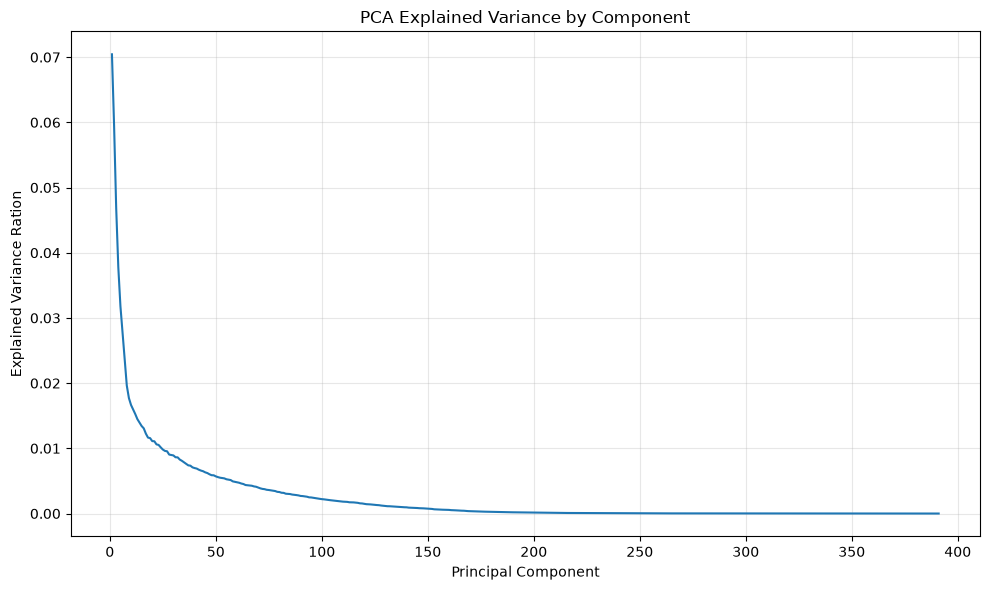

In [11]:
# Visualize the variance contributed by individual principal components.

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=pca_variance,
    x="component",
    y="explained_variance_ratio",
    ax=ax,
)

ax.set(
    title="PCA Explained Variance by Component",
    xlabel="Principal Component",
    ylabel="Explained Variance Ration",
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The explained-variance curve shows how quickly the contribution of individual principal components declines.

A steep decline indicates that a relatively small number of components capture substantial variation. A gradual decline indicates that the selected feature space remains distributed across many dimensions.

The figure therefore provides evidence about the **degree of compressibility** of the feature space.

It does not by itself determine the appropriate number of clustering dimensions. That decision must also consider the resulting clustering behaviour in Notebook 04.

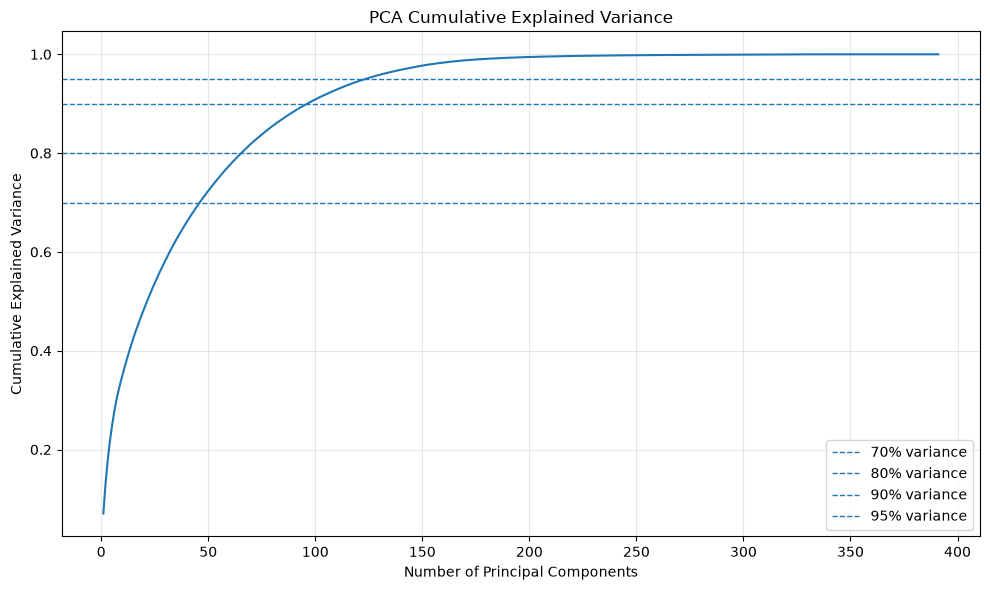

In [12]:
# Visualize the cumulative proportion of variance represented as additional
# principal components are retained.
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=pca_variance,
    x="component",
    y="cumulative_explained_variance",
    ax=ax,
)

for threshold in [0.70, 0.80, 0.90, 0.95]:
    ax.axhline(
        threshold,
        linestyle="--",
        linewidth=1,
        label=f"{threshold:.0%} variance"
    )

ax.set(
    title="PCA Cumulative Explained Variance",
    xlabel="Number of Principal Components",
    ylabel="Cumulative Explained Variance",
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The cumulative explained-variance curve shows how many principal components are required to retain progressively larger proportions of the variation in the selected feature space.

The reference levels at 70%, 80%, 90%, and 95% make the dimensionality-versus-retention trade-off explicit.

A large gap between the original feature count and the component count required for a given variance level would indicate substantial dimensionality reduction.

The 90% level is used later as the project's transparent working reference for the primary PCA representation. This remains a candidate representation rather than a final clustering decision.

In [13]:
# Quantify the number of components required to reach the principal
# cumulative variance reference points.
variance_thresholds = pd.DataFrame(
    {
        "variance_threshold": [0.70, 0.80, 0.90, 0.95],
        "components_required": [
            int(
                np.searchsorted(
                    pca_variance["cumulative_explained_variance"].to_numpy(),
                    threshold,
                )
                + 1
            )
            for threshold in [0.70, 0.80, 0.90, 0.95]
        ],
    }
)

variance_thresholds

,variance_threshold,components_required
0,0.70,46
1,0.80,66
2,0.90,97
3,0.95,124


### Interpretation

The table converts the cumulative-variance curve into explicit component counts.

Each row answers a different question: how many dimensions are required to retain the specified proportion of variation?

The 90% row is the primary working reference because it provides a transparent and reproducible dimensionality-reduction rule.

The other thresholds remain useful for understanding how sensitive the dimensionality decision is to the amount of variance retained.

In [14]:
# Calculate the percentage reduction in dimensionality associated with each
# variance retention reference point.
variance_thresholds["feature_reduction_pct"] = (
    1
    - variance_thresholds["components_required"]
    / X_selected.shape[1]
) * 100

variance_thresholds

,variance_threshold,components_required,feature_reduction_pct
0,0.70,46,88.235294
1,0.80,66,83.120205
2,0.90,97,75.191816
3,0.95,124,68.286445


### Interpretation

The feature-reduction percentage expresses the dimensionality trade-off in relative terms.

For example, a high percentage means that a large portion of the original selected feature space can be removed while retaining the corresponding variance threshold.

This is useful for assessing whether PCA provides a practically meaningful reduction rather than merely a mathematically smaller representation.

The table does not establish that greater dimensionality reduction is automatically better. Excessive reduction can remove structure that may be relevant to clustering.

## 7. Principal Component Loadings

Explained variance establishes how much variation the principal components represent, but it does not explain what those components represent.

The leading PCA loadings are therefore examined to determine which prepared survey features contribute most strongly to the dominant components.

Because the analytical representation contains binary and one-hot encoded variables, PCA components should be interpreted as **combinations of survey-response patterns**, rather than as individual survey questions.

The loading analysis is descriptive and is used later to support interpretation of cluster structure.

In [15]:
# Convert the fitted PCA component coefficients into a feature-level table
# so that the leading components can be interpreted against the selected data.
pca_loadings = pd.DataFrame(
    pca_full.components_,
    columns=X_selected_scaled.columns,
    index=[
        f"PC{i}"
        for i in range(1, pca_full.n_components_ + 1)
    ],
)

pca_loadings.iloc[:5].T

,PC1,PC2,PC3,PC4,PC5
age__What is your age?,0.224148,0.181169,-0.113054,0.716683,0.410615
binary__Is your primary role within your company related to tech/IT?,-0.000511,0.001763,-0.004610,-0.006366,-0.002015
binary__Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,-0.044031,-0.093715,0.010899,0.013119,0.030707
binary__Have you ever sought treatment for a mental health issue from a mental health professional?,0.227263,-0.131380,-0.068897,-0.087741,0.041142
binary__work_position__Back-end Developer,-0.052305,-0.006076,-0.006798,-0.081062,0.008539
binary__work_position__Designer,0.026186,0.012826,0.001352,-0.029239,-0.001557
binary__work_position__Dev Evangelist/Advocate,0.002413,-0.007681,-0.013231,-0.000070,-0.005676
binary__work_position__DevOps/SysAdmin,-0.009291,0.010032,-0.010897,-0.018366,0.013858
binary__work_position__Executive Leadership,0.014014,0.025942,-0.009829,0.013436,-0.002734
binary__work_position__Front-end Developer,-0.014545,0.005567,0.028208,-0.074699,-0.016592


### Interpretation

Each row represents one principal component, while each column represents a selected survey feature.

The loading coefficient indicates the direction and strength with which a feature contributes to that component.

Positive and negative loadings represent opposing directions along the component.

Because the feature space contains encoded categorical variables, a component should therefore be interpreted as a **multivariate response pattern**, not as a single latent survey question.

In [16]:
# Identify the strongest absolute loadings across the first five principal
# components to focus interpretation on the dominant transformed dimensions.
leading_loadings = (
    pca_loadings.iloc[:5]
    .T
    .assign(
        maximum_absolute_loading=lambda data: data.abs().max(axis=1)
    )
    .sort_values(
        "maximum_absolute_loading",
        ascending=False,
    )
)

leading_loadings.head(20)

,PC1,PC2,PC3,PC4,PC5,maximum_absolute_loading
age__What is your age?,0.224148,0.181169,-0.113054,0.716683,0.410615,0.716683
categorical__Did your previous employers provide resources to learn more about mental health issues and how to seek help?_None did,-0.013853,0.097892,0.071765,-0.163981,0.359375,0.359375
categorical__Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?_None did,0.016004,0.073961,0.051526,-0.109405,0.334604,0.334604
categorical__Were you aware of the options for mental health care provided by your previous employers?_N/A (not currently aware),-0.086274,0.100382,0.062623,-0.134877,0.274895,0.274895
categorical__Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?_I don't know,-0.043347,0.064453,0.007644,-0.066575,0.272284,0.272284
categorical__Do you know the options for mental health care available under your employer-provided coverage?_Missing,0.104444,0.255891,-0.019737,-0.096082,-0.046604,0.255891
categorical__Do you believe your productivity is ever affected by a mental health issue?_Missing,-0.127521,-0.250903,0.045330,0.054899,0.071680,0.250903
categorical__Have you been diagnosed with a mental health condition by a medical professional?_Yes,0.231877,-0.148106,-0.055580,-0.106328,0.065339,0.231877
"categorical__If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?_Not applicable to me",-0.231107,0.137058,0.068408,0.106721,-0.050723,0.231107
categorical__Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?_No,-0.151140,-0.229784,0.007039,0.042456,0.081777,0.229784


### Interpretation

The table identifies the features with the strongest contributions across the leading five principal components.

The `maximum_absolute_loading` column is used only to rank features by the magnitude of their contribution.

This does not mean that the highest-loading feature is independently responsible for a component. Each component is a weighted combination of many features.

The table is therefore primarily useful for identifying the survey-response variables that deserve attention when interpreting the broad structure captured by PCA.

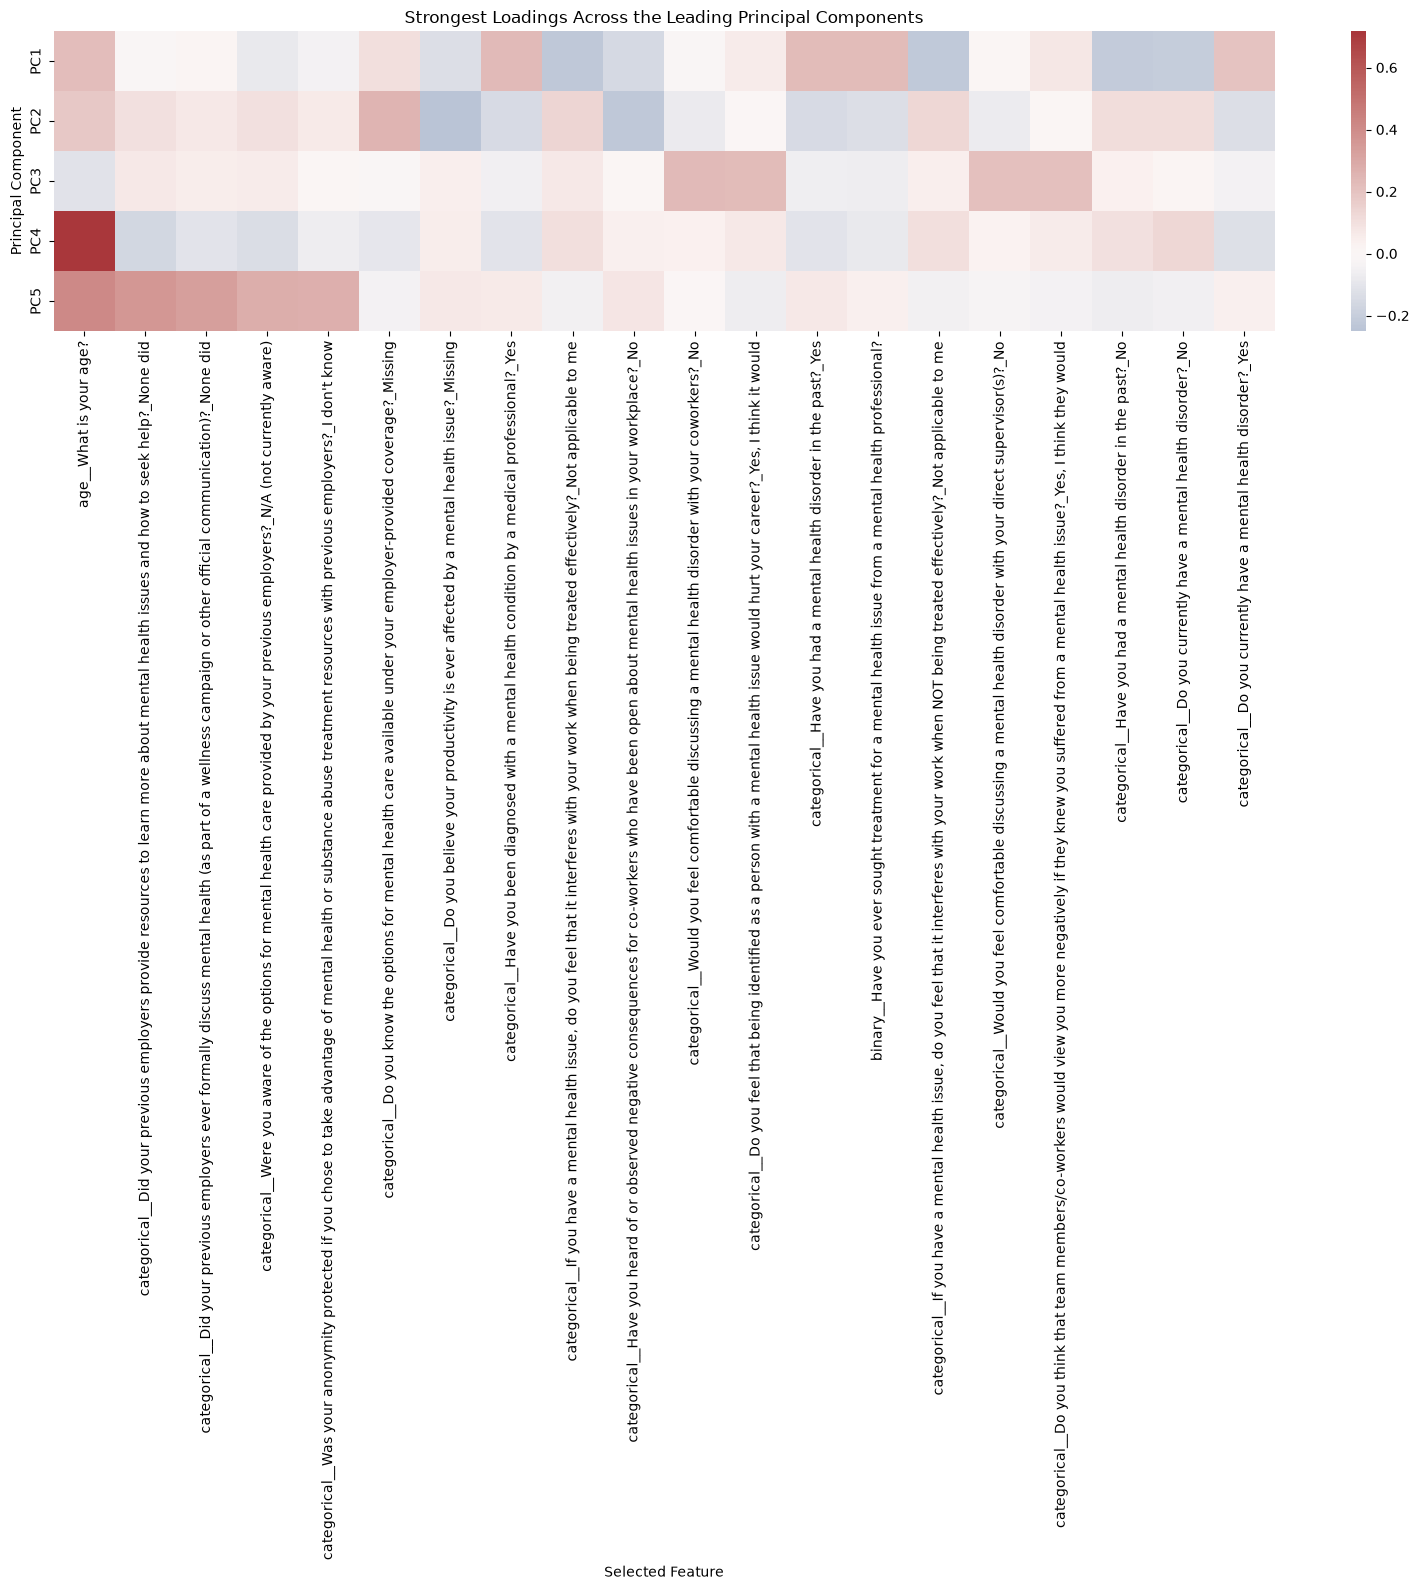

In [17]:
# Visualize the strongest structure while retating the sign of each
# feature contribution to the leading principal components.
loading_matrix = leading_loadings.head(20).drop(
    columns="maximum_absolute_loading"
).T

fig, ax = plt.subplots(figsize=(16, 16))

sns.heatmap(
    loading_matrix,
    cmap="vlag",
    center=0,
    ax=ax
)

ax.set(
    title="Strongest Loadings Across the Leading Principal Components",
    xlabel="Selected Feature",
    ylabel="Principal Component",
)

plt.tight_layout()
plt.show()

### Interpretation

The heatmap shows the direction and relative magnitude of the strongest feature contributions across the leading components.

Features with large positive loadings contribute strongly in one direction, while large negative loadings contribute in the opposite direction.

The visual grouping of similarly loading variables can provide evidence that a principal component represents a broader combination of related survey-response patterns.

The heatmap should not be interpreted as a causal relationship between the variables. PCA describes covariance structure in the analytical representation; it does not establish causality.

## 8. PCA Representation for Subsequent Clustering

The full PCA model has now been fitted and evaluated.

The 90% cumulative explained-variance point is used as the **initial working representation** for the clustering stage.

Importantly, the PCA model is **not refitted** at this component count.

Instead:

1. PCA is fitted once using the complete selected feature space;
2. the cumulative explained-variance profile identifies the required component count;
3. the already fitted PCA transformation is truncated to those leading components.

This preserves a single, consistent PCA basis and avoids introducing a second fitted transformation.

In [18]:
# Determine the number of components required to reach the 90% cumulative
# explained-variance reference point.

pca_component_count = int(
    variance_thresholds.loc[
        variance_thresholds["variance_threshold"] == PCA_VARIANCE_TARGET,
        "components_required",
    ].iloc[0]
)

# Retain the first components from the already fitted full PCA transformation.
X_pca = pd.DataFrame(
    X_pca_full.iloc[:, :pca_component_count],
    columns=[
        f"PC{i}"
        for i in range(1, pca_component_count + 1)
    ],
    index=X_selected_scaled.index,
)

pca_retained_variance = pca_variance.loc[
    pca_variance["component"] <= pca_component_count,
    "explained_variance_ratio",
].sum()

print(
    "PCA representation created: "
    f"{X_pca.shape[0]:,} observations x "
    f"{X_pca.shape[1]:,} components."
)

print(
    "Cumulative explained variance retained: "
    f"{pca_retained_variance:.0%}."
)

PCA representation created: 1,433 observations x 97 components.
Cumulative explained variance retained: 90%.


### Interpretation

The PCA representation is now defined using the first components required to reach the project's 90% cumulative-variance reference point.

The output provides two important pieces of information:

- the number of dimensions retained;
- the proportion of selected-feature variance represented by those dimensions.

The PCA representation is substantially lower-dimensional only if the retained component count is materially smaller than the selected feature count.

This representation becomes the **primary reduced candidate** for clustering in Notebook 04. Its final usefulness will be judged by clustering diagnostics rather than by explained variance alone.

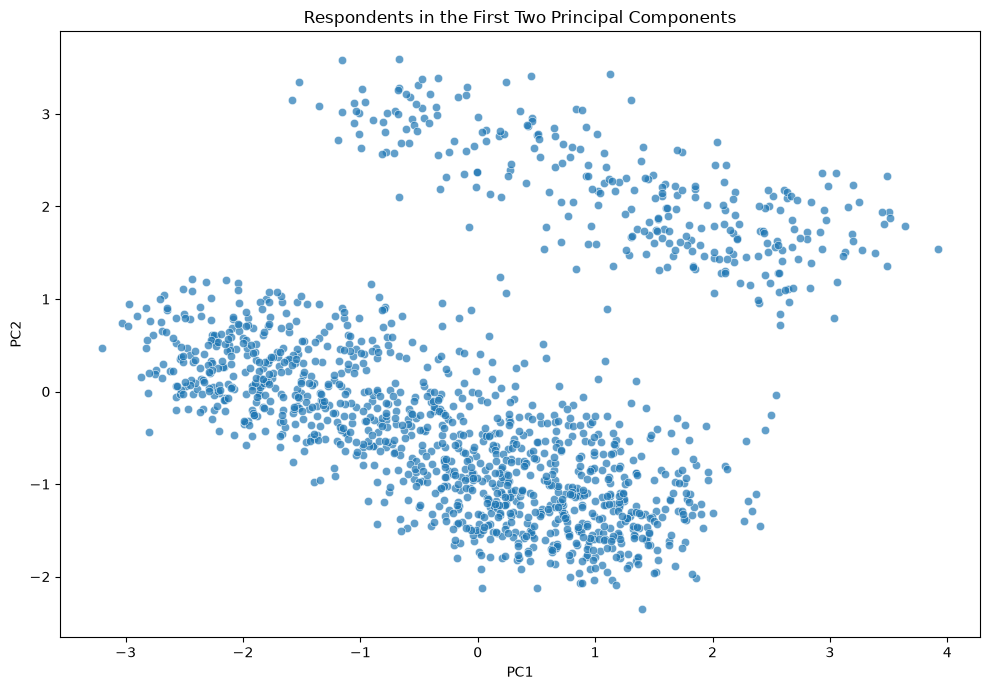

In [19]:
# Project respondents into the first two principal components for descriptive
# visual inspection of the reduced feature space.
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=X_pca,
    x="PC1",
    y="PC2",
    alpha=0.7,
    ax=ax,
)

ax.set(
    title="Respondents in the First Two Principal Components",
    xlabel="PC1",
    ylabel="PC2",
)

plt.tight_layout()
plt.show()

### Interpretation

The PCA projection provides a two-dimensional visual representation of respondent positions along the two dominant principal components.

Visible concentration, separation, overlap, or isolated observations are descriptive characteristics of the transformed feature space.

However, this figure does **not** establish a cluster count.

No clustering algorithm has been applied, and no cluster labels exist at this stage.

The figure is therefore used only to inspect the broad geometry of the respondent representation before formal clustering evaluation.

## 9. Multidimensional Scaling

### Question

Does a distance-based representation provide a useful complementary view of the selected feature space?

### Method

Metric MDS is applied to the mixed-scaled selected feature representation.

Unlike PCA, which identifies orthogonal directions that maximize variance, MDS seeks a low-dimensional configuration that preserves pairwise distances as closely as possible.

### Role in this project

MDS is treated as a **complementary dimensionality-reduction method**, not as the primary clustering representation.

Its purpose is to provide an alternative view of respondent relationships and determine whether broad geometric patterns are also visible under a distance-based transformation.

In [20]:
# Fit a reproducible two-dimensional MDS representation using the mixed-scaled
# selected feature space.
mds_model, X_mds = fit_mds(
    X_pca,
    n_components=2,
    random_state=RANDOM_STATE,
)

print(
    "MDS representation created: "
    f"{X_mds.shape[0]:,} observations x "
    f"{X_mds.shape[1]} dimensions."
)

print(
    "MDS Normalised Stress-1: "
    f"{mds_model.stress_:.4f}"
)

C:\Users\User\Documents\Projects\mental-health-in-tech-ml\.venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


MDS representation created: 1,433 observations x 2 dimensions.
MDS Normalised Stress-1: 0.4197


### Interpretation

The MDS output confirms the dimensionality of the complementary representation and reports its stress value.

MDS stress measures the discrepancy between the distances in the original feature space and the distances represented in the low-dimensional configuration.

Lower stress indicates a closer preservation of the original pairwise-distance structure.

The stress value should not be interpreted as a clustering-quality metric. It evaluates the fidelity of the MDS representation itself.

In [47]:
mds_model_3d, X_mds_3d = fit_mds(
    X_pca,
    n_components=3, # Increase dimensions
    random_state=RANDOM_STATE,
)
print(f"3D MDS Normalized Stress: {mds_model_3d.stress_:.4f}")

C:\Users\User\Documents\Projects\mental-health-in-tech-ml\.venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


3D MDS Normalized Stress: 0.3010


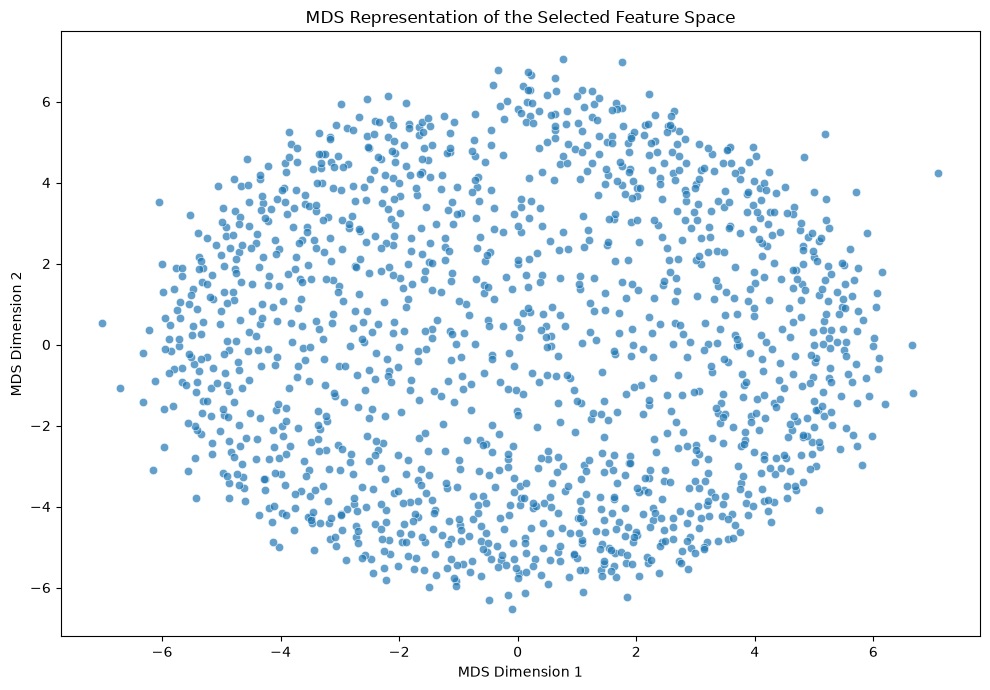

In [40]:
# Visualize the MDS representation so that its respondent-level geometry can
# be examined independently from the PCA projection.

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=X_mds,
    x="MDS1",
    y="MDS2",
    alpha=0.7,
    ax=ax,
)

ax.set(
    title="MDS Representation of the Selected Feature Space",
    xlabel="MDS Dimension 1",
    ylabel="MDS Dimension 2",
)

plt.tight_layout()
plt.show()

### Interpretation

The MDS projection provides a distance-based view of the same respondent population.

The figure can be compared descriptively with the PCA projection to determine whether broad concentrations or separation patterns appear consistently across two different representations.

Agreement would provide supporting evidence that the observed geometry is not solely a consequence of PCA's variance-maximizing transformation.

Differences would indicate that the apparent structure is representation-dependent.

MDS therefore remains a complementary diagnostic rather than the primary clustering input.

## 10. Locally Linear Embedding

Locally Linear Embedding (LLE) is considered separately because it assumes that observations lie on a lower-dimensional manifold whose local relationships can be reconstructed from neighbouring observations.

The prepared analytical representation is dominated by binary and one-hot encoded survey indicators. The project has not established evidence that these encoded survey responses form a smooth locally linear manifold.

Applying LLE solely because it is available would therefore introduce an additional modelling assumption without sufficient evidence that the assumption is appropriate for this dataset.

### Decision

LLE is **not included in the primary dimensionality-reduction experiment set**.

This is a deliberate methodological decision rather than an omission.

PCA provides the primary reduced representation, while MDS provides a complementary distance-based representation.

The clustering stage can therefore compare meaningful representations without introducing an unsupported manifold assumption.

## 11. Dimensionality-Reduction Summary

The dimensionality-reduction stage has now produced three analytically distinct representations:

- **Selected features** — the feature-selected representation before scaling.
- **Mixed-scaled selected features** — the selected representation with continuous variables standardized while binary/one-hot features remain 0/1. This is the no-reduction clustering baseline.
- **PCA** — the primary reduced representation based on the 90% cumulative explained-variance reference point.
- **MDS** — a complementary two-dimensional distance-based representation.

LLE was considered but excluded because the available analytical evidence does not sufficiently justify its locally linear manifold assumptions.

The clustering stage in Notebook 04 will determine whether the PCA representation actually produces more useful cluster structure than the selected/no-reduction representation.

No clustering conclusion is drawn from this notebook alone.

In [41]:
# Summarize the analytical representations produced during this notebook.

representation_summary = pd.DataFrame(
    {
        "representation": [
            "Prepared analytical matrix",
            "Selected features",
            "Mixed-scaled selected features",
            "PCA",
            "MDS",
        ],
        "observations": [
            X_prepared.shape[0],
            X_selected.shape[0],
            X_selected_scaled.shape[0],
            X_pca.shape[0],
            X_mds.shape[0],
        ],
        "dimensions": [
            X_prepared.shape[1],
            X_selected.shape[1],
            X_selected_scaled.shape[1],
            X_pca.shape[1],
            X_mds.shape[1],
        ],
    }
)

representation_summary

,representation,observations,dimensions
0,Prepared analytical matrix,1433,495
1,Selected features,1433,391
2,Mixed-scaled selected features,1433,391
3,PCA,1433,97
4,MDS,1433,2


### Interpretation

The summary provides a direct view of the dimensionality changes introduced at each stage.

The prepared matrix represents the full analytical input from Notebook 02.

The selected representation reflects unsupervised removal of constant and highly redundant features.

The mixed-scaled representation preserves the same selected dimensionality while changing only the scale of continuous variables.

The PCA representation provides the principal dimensionality reduction used for the subsequent clustering experiments.

The MDS representation is intentionally limited to two dimensions because its role is complementary structural visualization rather than the primary clustering representation.

## 12. Persist the Analytical Representations

The dimensionality-reduction stage now produces the reusable analytical inputs required by Notebook 04.

The following artifacts are persisted:

1. `mental_health_selected.csv` — selected features before scaling;
2. `mental_health_selected_scaled.csv` — selected features after mixed-feature scaling;
3. `mental_health_pca.csv` — primary PCA representation;
4. `mental_health_mds.csv` — complementary MDS representation.

Persisting these artifacts makes the transition into clustering explicit and prevents Notebook 04 from silently repeating feature selection, scaling, or dimensionality reduction.

The PCA model itself is not persisted because Notebook 04 requires the analytical representation rather than a deployment model.

In [42]:
# Persist the analytical representations required by the clustering stage.

processed_directory = Path("../data/processed")
processed_directory.mkdir(parents=True, exist_ok=True)

X_selected.to_csv(
    processed_directory / "mental_health_selected.csv", index=False
)

X_selected_scaled.to_csv(
    processed_directory / "mental_health_selected_scaled.csv", index=False
)

X_pca.to_csv(
    processed_directory / "mental_health_pca.csv", index=False
)

X_mds.to_csv(
    processed_directory / "mental_health_mds.csv", index=False
)

print("Dimensionality-reduction artifacts saved:")
print(" - data/processed/mental_health_selected.csv")
print(" - data/processed/mental_health_selected_scaled.csv")
print(" - data/processed/mental_health_pca.csv")
print(" - data/processed/mental_health_mds.csv")

Dimensionality-reduction artifacts saved:
 - data/processed/mental_health_selected.csv
 - data/processed/mental_health_selected_scaled.csv
 - data/processed/mental_health_pca.csv
 - data/processed/mental_health_mds.csv


### Interpretation

The output confirms that all four analytical representations required by the next stage have been persisted.

This creates a clear boundary between Notebook 03 and Notebook 04:

- Notebook 03 determines the analytical representations.
- Notebook 04 consumes those representations and performs clustering experiments.

Persisting the matrices also ensures that Notebook 04 does not silently perform a second round of feature selection or scaling.

## 13. Final Artifact Validation

Before leaving the dimensionality-reduction stage, each persisted analytical representation is validated.

The validation confirms that:

- every representation contains the same respondents;
- respondent ordering remains aligned;
- all values are numerical and finite;
- dimensionality is internally consistent.

This protects the handoff into Notebook 04 from accidental row misalignment or invalid numerical values.

In [43]:
# Validate the dimensions, respondent alignment, and numerical completeness of
# every representation that will be consumed by the clustering stage.

representations = {
    "selected": X_selected,
    "selected_scaled": X_selected_scaled,
    "pca": X_pca,
    "mds": X_mds,
}

for name, representation in representations.items():
    if len(representation) != len(X_prepared):
        raise ValueError(
            f"{name} representation does not preserve the respondent count."
        )

    if not representation.index.equals(X_prepared.index):
        raise ValueError(
            f"{name} representation does not preserve respondent index alignment."
        )

    if not all(
        pd.api.types.is_numeric_dtype(dtype)
        for dtype in representation.dtypes
    ):
        raise TypeError(
            f"{name} representation contains non-numerical features."
        )

    if not np.isfinite(representation.to_numpy()).all():
        raise ValueError(
            f"{name} representation contains non-finite values."
        )

print(
    "All dimensionality-reduction representations passed final validation."
)

All dimensionality-reduction representations passed final validation.


### Interpretation

A successful validation confirms that all representations preserve the original respondent population and remain suitable for numerical analysis.

This is the final technical handoff check before clustering.

The validation does not assess whether PCA, MDS, or the selected representation is substantively superior. That question belongs to Notebook 04, where the representations are evaluated through the clustering models and their corresponding diagnostics.

## Conclusion

The dimensionality-reduction stage has completed the transition from the prepared survey representation to analytically defined feature spaces for clustering.

The analysis first applied conservative unsupervised feature selection. Constant features were removed where present, followed by redundancy filtering based on very high absolute correlation. This reduced duplicated information without introducing a supervised target or arbitrarily removing rare survey responses.

The selected representation contains continuous variables together with binary and one-hot encoded survey features. Rather than standardizing every encoded variable, the analysis explicitly preserves binary and one-hot variables as 0/1 and standardizes only continuous variables. This produces a mixed-feature representation that avoids changing the numerical meaning of categorical indicators while preventing continuous variables from dominating solely because of their original measurement scale.

PCA was then fitted once across the complete mixed-scaled selected representation. The complete explained-variance structure was examined before determining the number of components required to reach the 90% cumulative-variance reference point. The resulting PCA representation is retained as the primary reduced candidate for clustering.

The PCA loadings provide additional evidence about which prepared survey features contribute most strongly to the dominant transformed dimensions. These loadings will support later interpretation but are not treated as causal or supervised feature importance.

MDS was evaluated as a complementary distance-based representation. Its stress value and respondent projection provide an alternative view of the geometry of the selected feature space. MDS is not treated as a replacement for PCA or as evidence of a particular number of clusters.

LLE was considered but excluded because the prepared survey representation does not provide sufficient methodological justification for assuming a locally linear manifold structure.

The following representations are therefore available for Notebook 04:

- selected features without scaling;
- mixed-scaled selected features for the no-reduction clustering baseline;
- the PCA representation based on the 90% cumulative-variance reference point;
- the complementary two-dimensional MDS representation.

The clustering stage will determine whether these representations produce useful and interpretable cluster structure through the project-defined evaluation criteria.

**No clustering conclusion is drawn from this notebook alone.**

In [46]:
# Fit a clean 2D t-SNE projection from your PCA space
X_tsne = fit_tsne(
    X_pca,
    perplexity=30,  # Tune this (e.g., 30 to 50) based on your cluster densities
    random_state=RANDOM_STATE,
)

print(
    "t-SNE layout created: "
    f"{X_tsne.shape[0]:,} observations x "
    f"{X_tsne.shape[1]} dimensions."
)

t-SNE layout created: 1,433 observations x 2 dimensions.


In [22]:
# Extract the loading vectors (components_ layout is: n_components x n_features)
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i}" for i in range(1, pca_full.n_components_ + 1)],
    index=X_selected_scaled.columns  # Map back to original feature names
)

# Look at the original features that heavily influence Principal Component 1 (PC1)
print("\nTop positive drivers for PC1:\n")
print(loadings["PC1"].sort_values(ascending=False).head(5))

print("\nTop negative drivers for PC1:\n")
print(loadings["PC1"].sort_values(ascending=True).head(5))


Top positive drivers for PC1:

categorical__Have you been diagnosed with a mental health condition by a medical professional?_Yes     0.231877
categorical__Have you had a mental health disorder in the past?_Yes                                    0.227590
binary__Have you ever sought treatment for a mental health issue from a mental health professional?    0.227263
age__What is your age?                                                                                 0.224148
categorical__Do you currently have a mental health disorder?_Yes                                       0.201036
Name: PC1, dtype: float64

Top negative drivers for PC1:

categorical__If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?_Not applicable to me                                                      -0.231107
categorical__If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?_Not applic

C:\Users\User\AppData\Local\Temp\ipykernel_16028\1103622112.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc1_loadings.values, y=pc1_loadings.index, palette="vlag")
C:\Users\User\AppData\Local\Temp\ipykernel_16028\1103622112.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


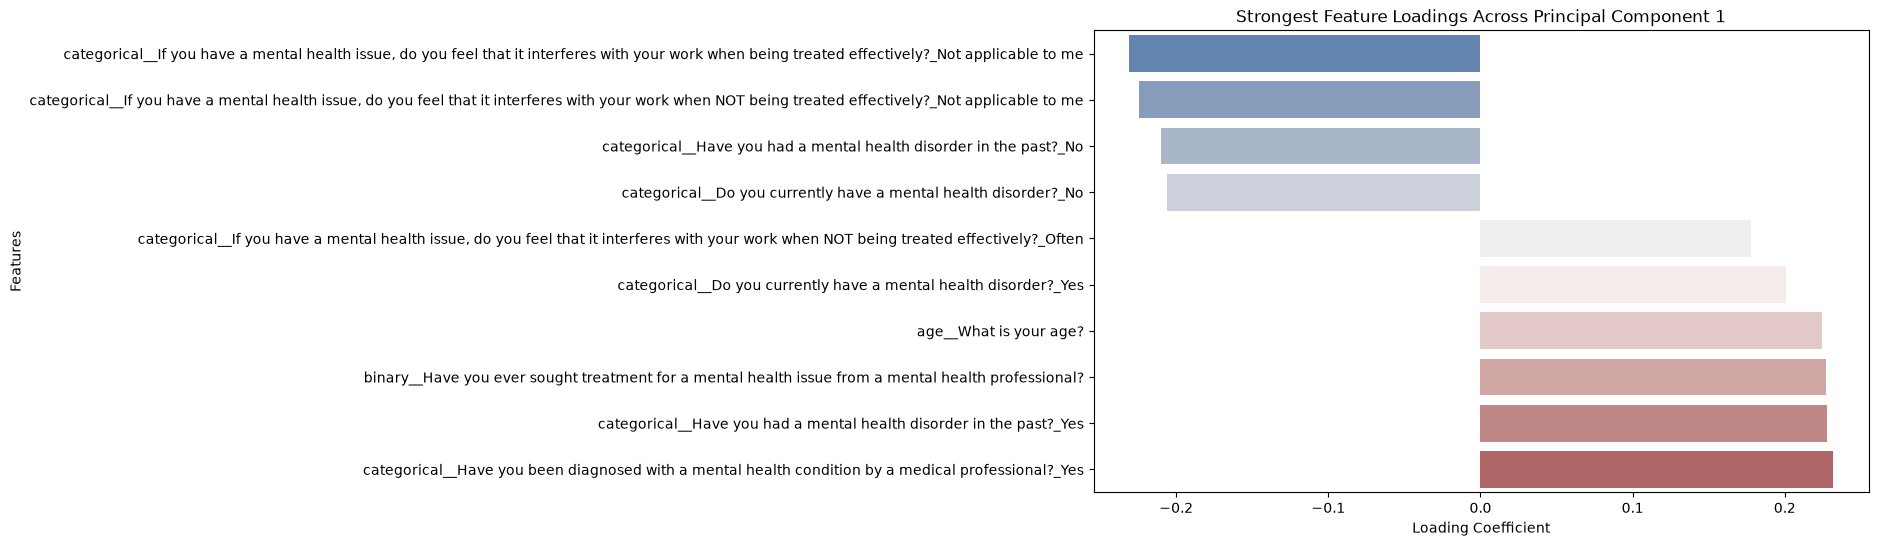

In [26]:
# Isolate the top drivers for Principal Component 1
top_pc1_features = loadings["PC1"].abs().sort_values(ascending=False).head(10).index
pc1_loadings = loadings.loc[top_pc1_features, "PC1"].sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=pc1_loadings.values, y=pc1_loadings.index, palette="vlag")
plt.title("Strongest Feature Loadings Across Principal Component 1")
plt.xlabel("Loading Coefficient")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [27]:
# Fit the UMAP reduction using the primary PCA space matrix
umap_model, X_umap, umap_trustworthiness = fit_umap(
    X_pca,
    n_neighbors=15,  # Balanced choice between local and global structure
    min_dist=0.1,    # Allows tight cluster visualization
    random_state=RANDOM_STATE
)

print(
    "UMAP representation created: "
    f"{X_umap.shape[0]:,} observations x "
    f"{X_umap.shape[1]} dimensions."
)

print(f"Embedding Trustworthiness Score: {umap_trustworthiness:.4f}")


UMAP representation created: 1,433 observations x 2 dimensions.
Embedding Trustworthiness Score: 0.8981


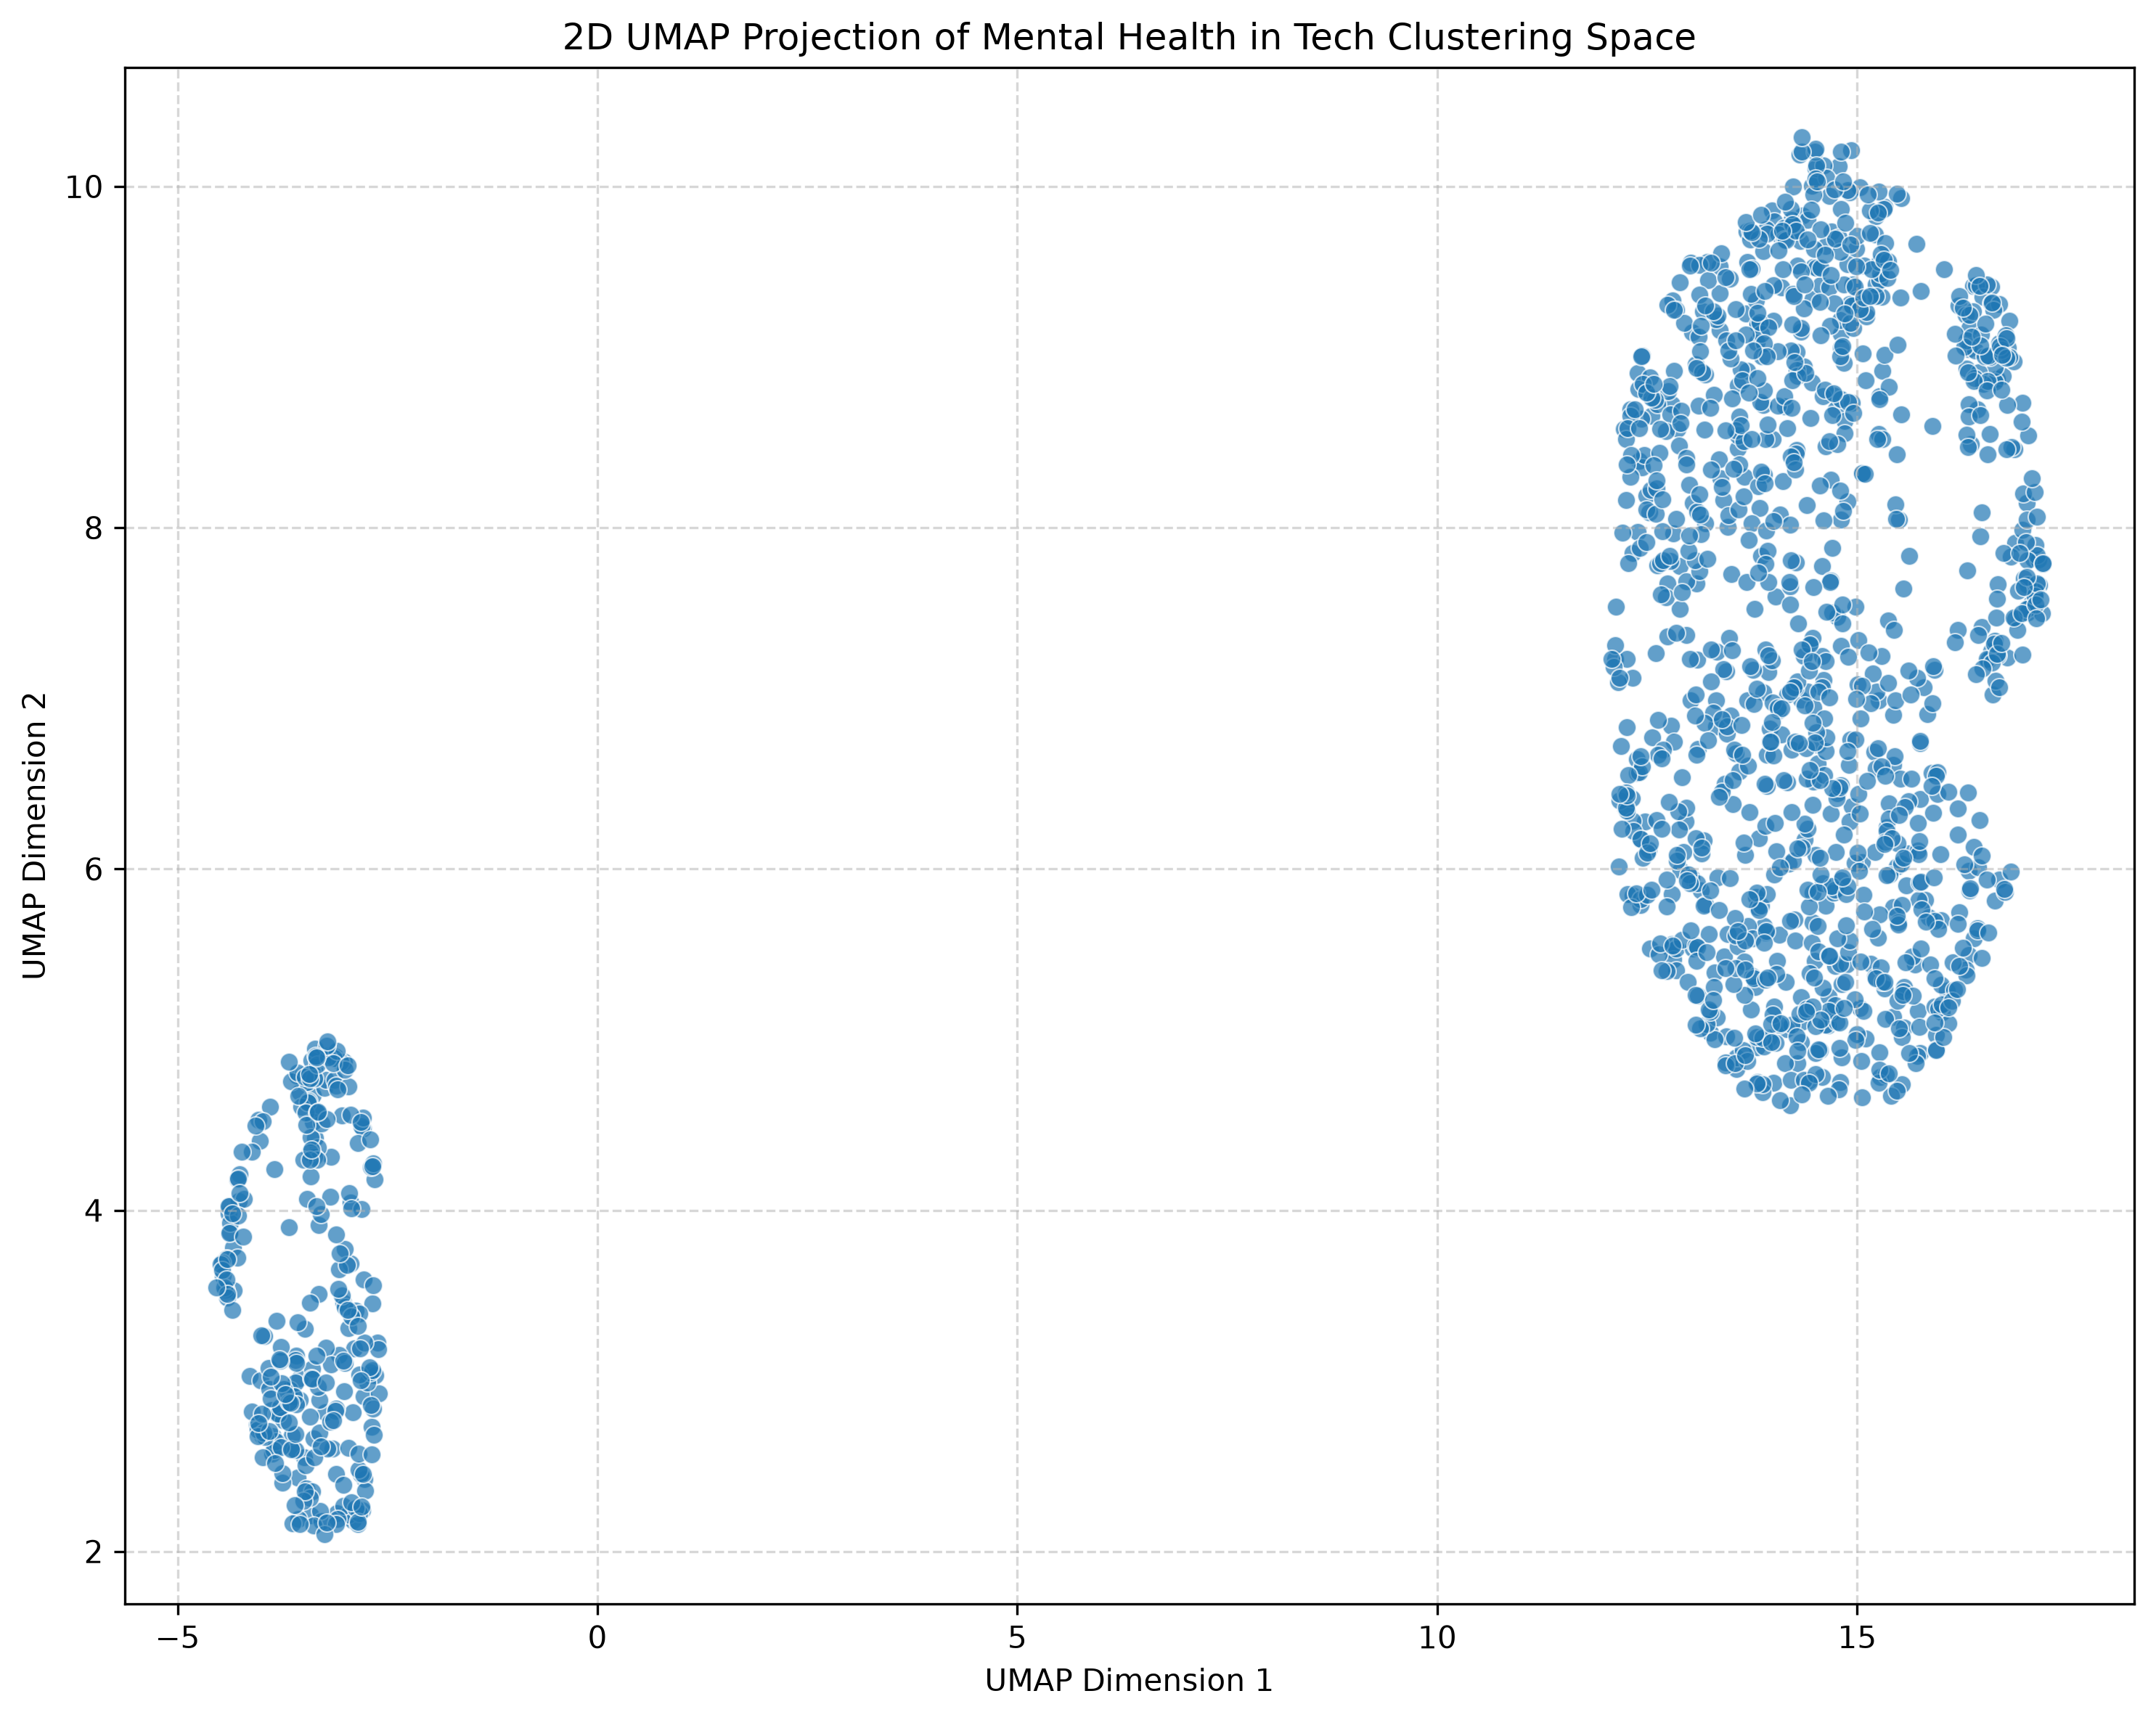

In [29]:
# Construct the visualization
plt.figure(figsize=(10, 8), dpi=300)
sns.scatterplot(
    x="UMAP1",
    y="UMAP2",
    data=X_umap,
    alpha=0.7,
    edgecolor="w",
    linewidth=0.5
)

plt.title("2D UMAP Projection of Mental Health in Tech Clustering Space")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

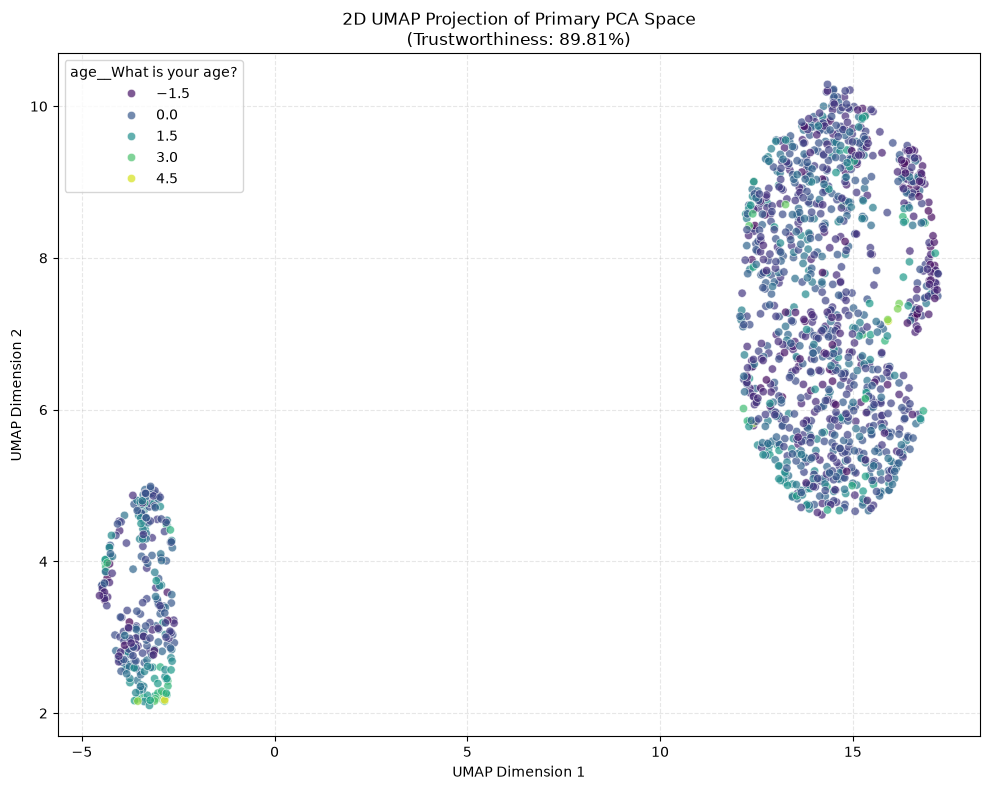

In [37]:
# Create the canvas
plt.figure(figsize=(10, 8))

# Map a feature (e.g., if you want to see how a specific column splits your clusters)
# Replace 'treatment' with any column name from your original dataset if desired
sns.scatterplot(
    x="UMAP1",
    y="UMAP2",
    data=X_umap,
    hue=X_selected_scaled["age__What is your age?"],
    alpha=0.7,
    palette="viridis",
    edgecolor="w",
    linewidth=0.5
)

plt.title("2D UMAP Projection of Primary PCA Space\n(Trustworthiness: 89.81%)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../reports/figures/umap_projection_of_leading_principal_components.png", 
    dpi=300, 
    bbox_inches="tight"
)
plt.show()